# **Figures Color**

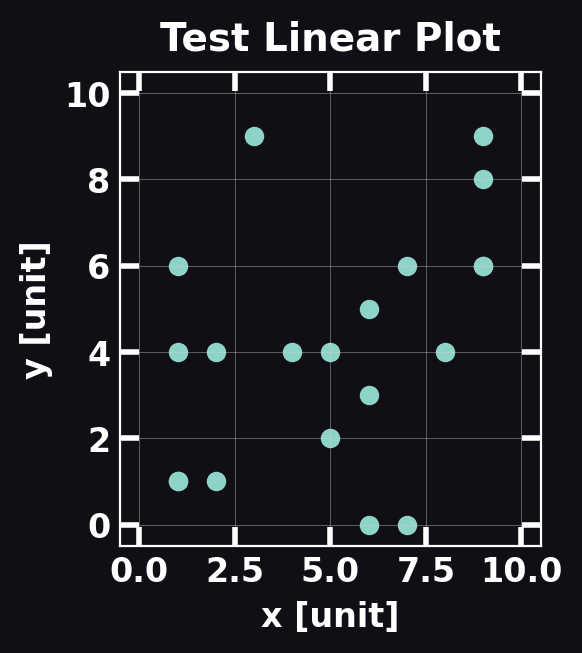

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from darksun.show import DSPlot

    
def set_figs_darkbkg(
    color: str = '#120E16',
) -> None:
    """
    Configures figure facecolor for figures with dark bkg.
    """
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    RCPARAMS = {
        'figure.facecolor': color,
        'axes.facecolor': color,
        'savefig.facecolor': color,
    }
    plt.style.use('dark_background')
    mpl.rcParams.update(RCPARAMS)
    return None


SAVE_TO: str = '/home/edoardo/Desktop'
#SAVE_TO: str = '/mnt/d/PhD_AASS/Coding/Images_fits'
DARK_BKG: bool = True
TRANSPARENT: bool = False

if DARK_BKG:
    color: str = '#120E16'
    set_figs_darkbkg(color)

dsp: DSPlot = DSPlot(1, 1)
fig, ax = dsp.config_subplots(size=3)
dsp.config_ticks(ax, [0, 2.5, 5.0, 7.5, 10.0])
dsp.config_labels(
    ax, 'Test Linear Plot', 'x [unit]', 'y [unit]',
)
ax.scatter(np.random.randint(0, 10, 20), np.random.randint(0, 10, 20))
dsp.config_axlim(ax, (-0.5, 10.5), (-0.5, 10.5))
fig.savefig(f'{SAVE_TO}/test.png', transparent=TRANSPARENT)
plt.show()

In [6]:
assert False

AssertionError: 

# PDFs Analysis

In [ ]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from typing import Any, Callable, NamedTuple
from pathlib import Path
from random import choices

import numpy as np
from numpy.typing import NDArray
import pandas as pd
from bisect import bisect_left, bisect_right

from bloodmoon.io import simulation_files
from bloodmoon.coords import shift2angle, equatorial2shift
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count, decode
from bloodmoon.mask import variance, snratio
from bloodmoon.optim import model_shadowgram

import darksun as ds
from darksun.types import Tag, LogEntry
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.utils import savefig_to

In [ ]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"
#DATA_FITS: str = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

ANALYSIS_ID: str = "singleCAM_iros_upx2upy1_newOptimiser"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 5
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = True

In [ ]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    run_name=ANALYSIS_ID,
)

wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)

filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

In [ ]:
class Source(NamedTuple):
    """
    Local frame coded-mask camera angular coordinates.

    Args:
        ID (str): Source name.
        angle_x (float): Angular coord along x-axis [deg]
        angle_y (float): Angular coord along y-axis [deg]
        flux (float): Source incoming flux [Crab]
    """
    ID: str
    angle_x: float
    angle_y: float
    flux: float


def simul_coords(
    n_sources: int,
    fov: tuple[int | float, int | float] = (-45, 45),
) -> tuple[tuple[float, float], ...]:
    """Simulates sources camera local-frame angular coords."""
    txs, tys = tuple(np.random.uniform(*fov, n_sources) for _ in range(2))
    return tuple((tx, ty) for tx, ty in zip(txs, tys))


def simul_coords(
    n_sources: int,
    *,
    fov_along_x: tuple[float, float] = (-45.0, 45.0),
    fov_along_y: tuple[float, float] = (-45.0, 45.0),
    pdf: Callable[[NDArray], NDArray] | None = None,
    sampling: int = 10_000,
) -> tuple[Coords, ...]:
    """
    Simulates sources camera local-frame angular coords
    in [deg] (also from custom PDF, if given).
    """
    def extract_coords(fov: tuple[float, float]) -> tuple[float, ...]:
        """Returns sources local-frame angular coords along single axis."""
        ground: NDArray = np.linspace(*fov, sampling + 1)
        weights: NDArray | None = pdf(ground) if pdf is not None else None
        return tuple(choices(ground, weights, k=n_sources))

    # NOTE: here is a little tricky, since this logic assumes a 1D PDF
    #   - should be generalised to a 2D PDF (where the axes are linked...)
    #   - otherwise, should insert as input `pdf_along_x`, and `pdf_along_y`
    txs: tuple[float, ...] = extract_coords(fov_along_x)
    tys: tuple[float, ...] = extract_coords(fov_along_y)
    return tuple((tx, ty) for tx, ty in zip(txs, tys))


def flux_pdf(
    pdf: Callable[[Any], NDArray],
    *args: Any,
    **kwargs: Any,
) -> Callable[[NDArray], NDArray]:
    """Initialises a sky-field sources flux PDF in [Crab]."""
    
    def f(flux: NDArray) -> NDArray:
        """Sky-field sources flux distribution in [Crab]."""
        return pdf(flux, *args, **kwargs)
    
    return f


def simul_fluxes(
    n_sources: int,
    f_min: int | float,
    f_max: int | float,
    pdf: Callable[[NDArray], NDArray] | None = None,
    sampling: int = 10_000,
) -> tuple[float, ...]:
    """Simulates sources fluxes in [Crab] (also from custom PDF, if given)."""
    f: NDArray = np.linspace(f_min, f_max, sampling + 1)
    weights: NDArray | None = pdf(f) if pdf is not None else None
    return tuple(choices(f, weights, k=n_sources))


def get_sources(
    coords: tuple[tuple[float, float], ...],
    fluxes: tuple[float, ...],
    IDs: tuple[str, ...] | None = None,
) -> tuple[Source, ...]:
    """
    Simulates the sky-field sources with IDs from input
    fluxes and camera local-frame angular coords values.
    """
    if not len(coords) == len(fluxes):
        raise ValueError("Input coords and fluxes tuples must have same length.")
    if IDs is None:
        IDs = tuple(f's{idx}' for idx in range(len(coords)))
    
    sources: tuple[Source, ...] = tuple(
        Source(id_, thx, thy, f) for id_, (thx, thy), f in zip(IDs, coords, fluxes)
    )
    return sources


# pdf(flux) in f_min, f_max
# compute cumulative and normalise in [0, 1]
# N numbers in [0, 1] (sources)
# scipy.interpolate.grid_data()

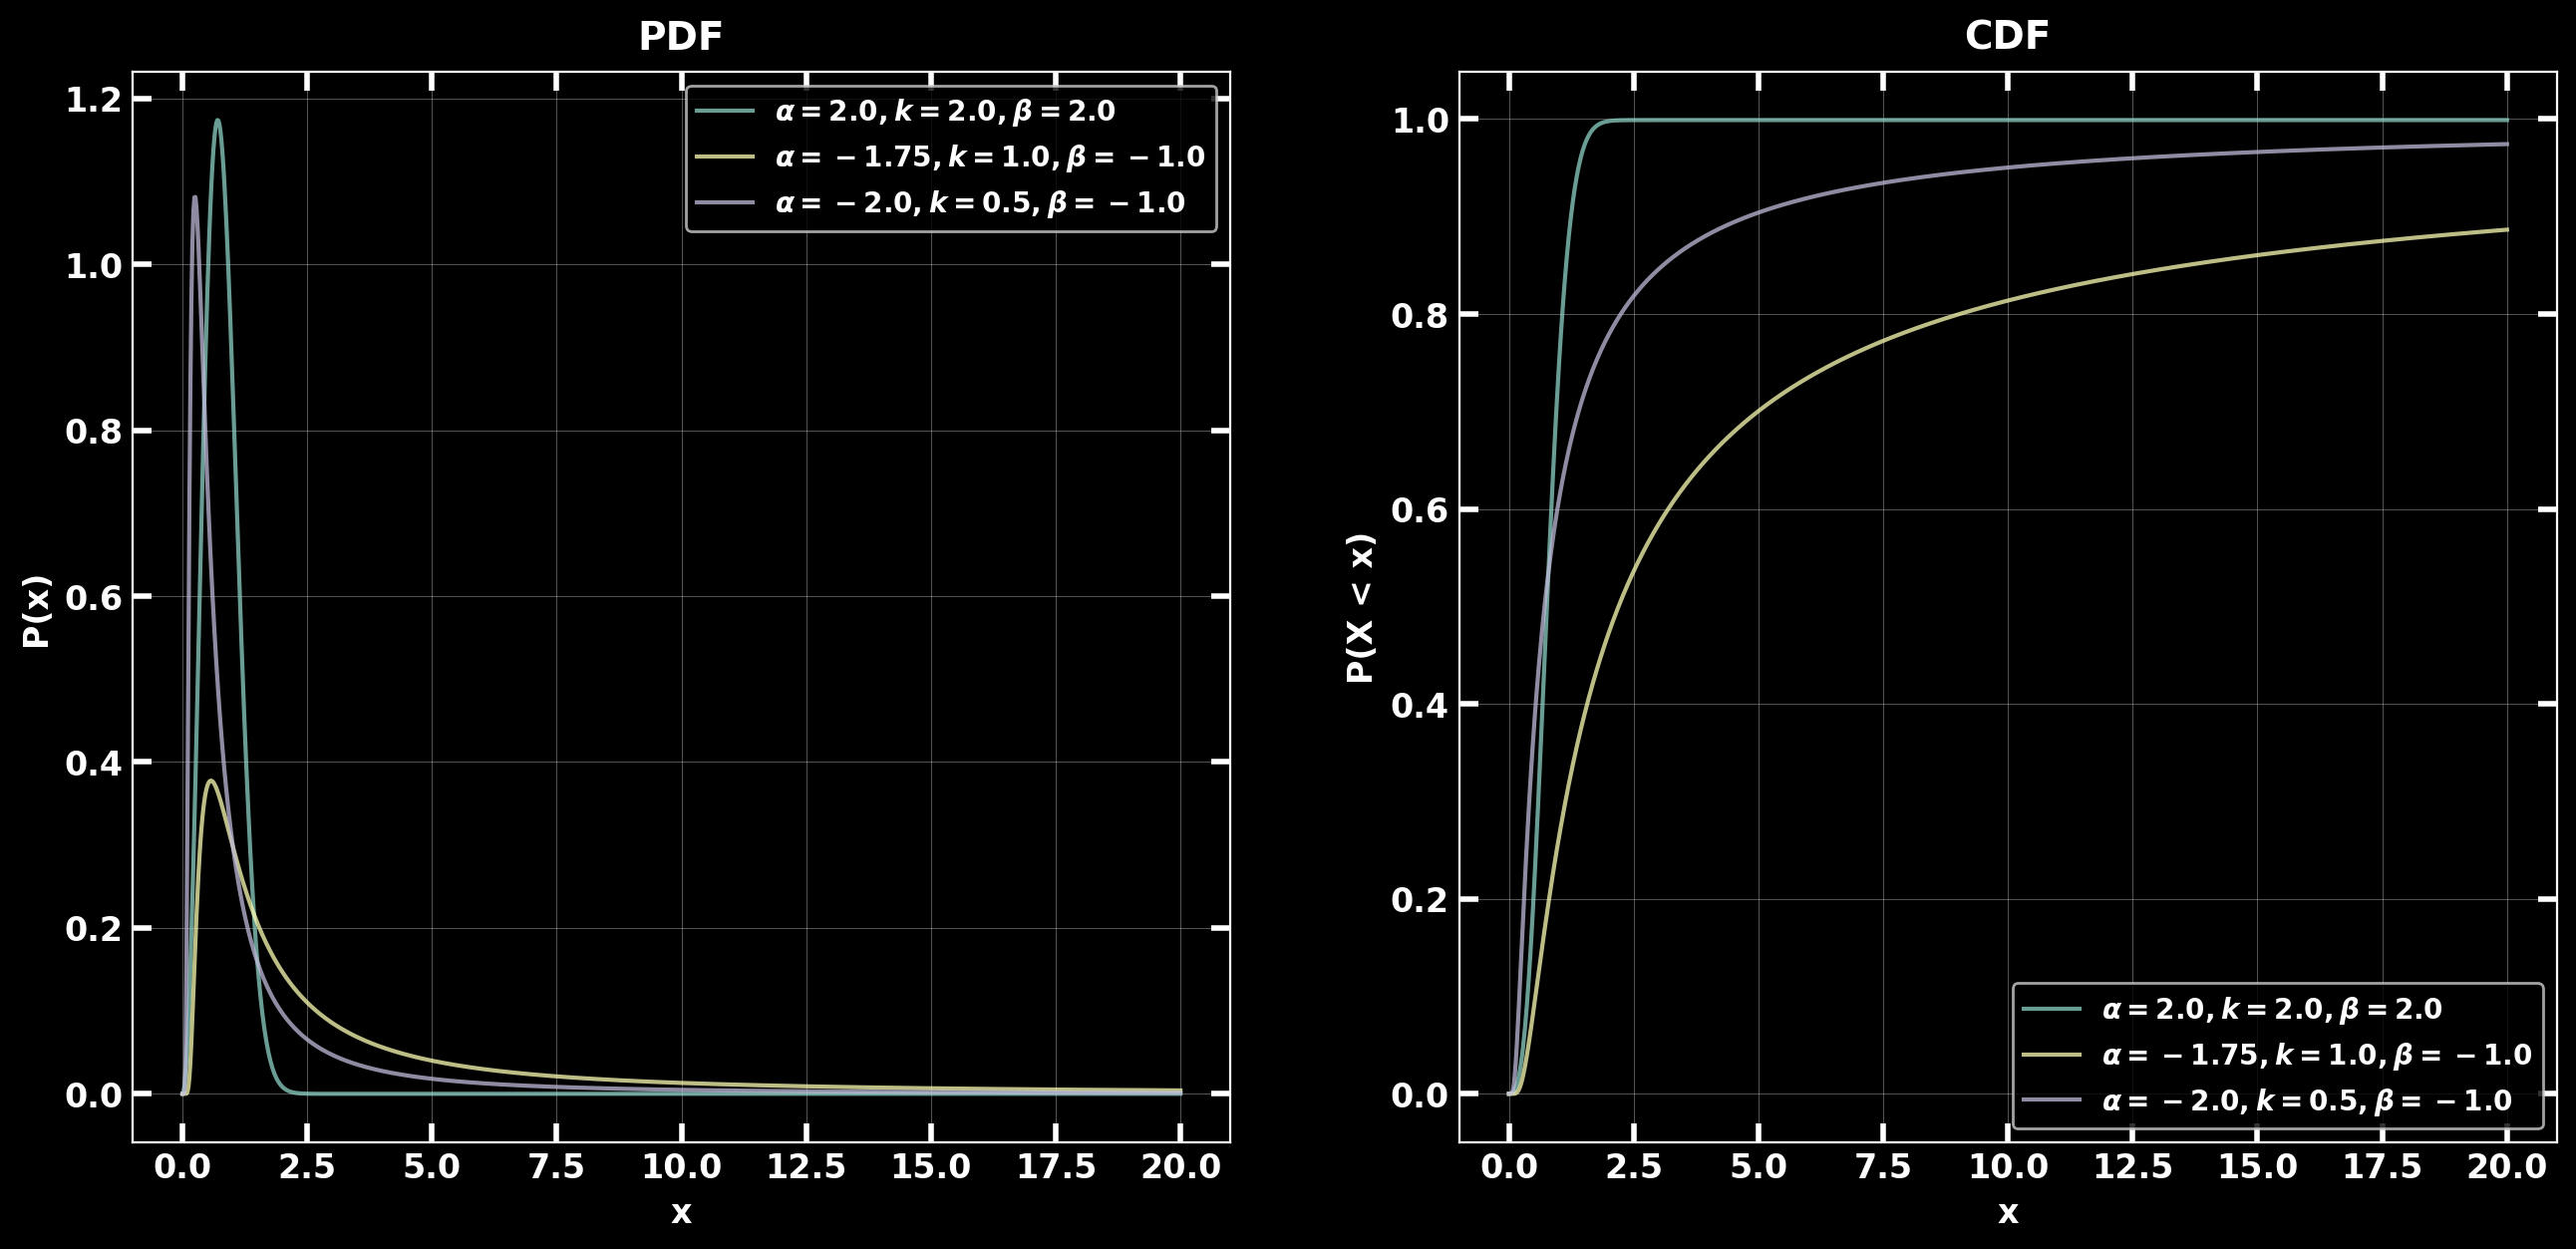

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')

from scipy.special import gamma

def mod_kernel(
    x: NDArray,
    alpha: float,
    k: float,
    beta: float,
) -> NDArray:
    """Custom exp - power law probability distribution function."""
    f = (alpha + 1) / beta
    A = beta * np.pow(k, f) / gamma(f)
    t = - k * np.pow(x, beta)
    return np.abs(A * np.pow(x, alpha) * np.exp(t))


# factors: tuple(alpha, k, beta)
factors = (
    (2.0, 2.0, 2.0),
    (-1.75, 1.0, -1.0),
    (-2.0, 0.5, -1.0),
)
flux_pdfs_ = tuple(
    flux_pdf(mod_kernel, alpha, k, beta) for (alpha, k, beta) in factors
)
labels_ = tuple(
    f'$\\alpha={alpha}, k={k}, \\beta={beta}$'
    for (alpha, k, beta) in factors
)


x = np.linspace(1e-8, stop:= 20, 1001)
dx = stop / len(x)
pdfs_ = tuple(f(x) for f in flux_pdfs_)

ds.plot(
    dmaps=(
        ds.map4plot(
            arrs=pdfs_,
            title='PDF',
            x=x,
            labels=labels_,
            ylabel='P(f)',
            xlabel='flux [Crab]',
            #color=('Aqua', 'DarkOrange'),
        ),
        ds.map4plot(
            arrs=tuple(map(lambda arr: np.cumsum(arr * dx), pdfs_)),
            title='CDF',
            x=x,
            labels=labels_,
            ylabel='P(Flux < f)',
            xlabel='flux [Crab]',
            #color=('DeepPink', 'SpringGreen'),
        ),
    ),
    ncols=2,
)

In [ ]:
n_sources: int = 5
fov: tuple[float, float] = (-40.0, 40.0)   # [deg]
f_min: int | float = 2.5e-2                # [Crab]
f_max: int | float = 10                    # [Crab]

factors = (2.0, 4.0, 2.0)
pdf: Callable[[NDArray], NDArray] = flux_pdf(mod_kernel, *factors)


_f: NDArray = np.linspace(1e-8, 20, 10_001)
_idx: int = np.argmax(pdf(_f))
print(f'P(x) mode: {_f[_idx]:.3f} Crab')

P(x) mode: 0.500 Crab


In [ ]:
coords = simul_coords(n_sources, fov=fov)

In [ ]:
fluxes = simul_fluxes(
    n_sources=n_sources,
    f_min=f_min,
    f_max=f_max,
    pdf=pdf,
)

fluxes

(np.float64(0.1736275),
 np.float64(0.85093),
 np.float64(0.306295),
 np.float64(0.42898749999999997),
 np.float64(0.5836),
 np.float64(0.7821024999999999),
 np.float64(0.4988125),
 np.float64(0.7032999999999999),
 np.float64(0.8519275),
 np.float64(0.72724),
 np.float64(0.25342749999999997),
 np.float64(0.557665),
 np.float64(0.5446975),
 np.float64(0.773125),
 np.float64(0.7042974999999999),
 np.float64(0.6903324999999999),
 np.float64(0.31228),
 np.float64(0.61552),
 np.float64(0.358165),
 np.float64(0.1417075),
 np.float64(0.3272425),
 np.float64(0.3950725),
 np.float64(0.7092849999999999),
 np.float64(0.23148249999999998),
 np.float64(0.5606574999999999),
 np.float64(0.41801499999999997),
 np.float64(0.5317299999999999),
 np.float64(0.5676399999999999),
 np.float64(0.25342749999999997),
 np.float64(0.4030525),
 np.float64(0.7601574999999999),
 np.float64(0.5097849999999999),
 np.float64(0.3591625),
 np.float64(0.57163),
 np.float64(0.6763675),
 np.float64(0.22050999999999998),
 np

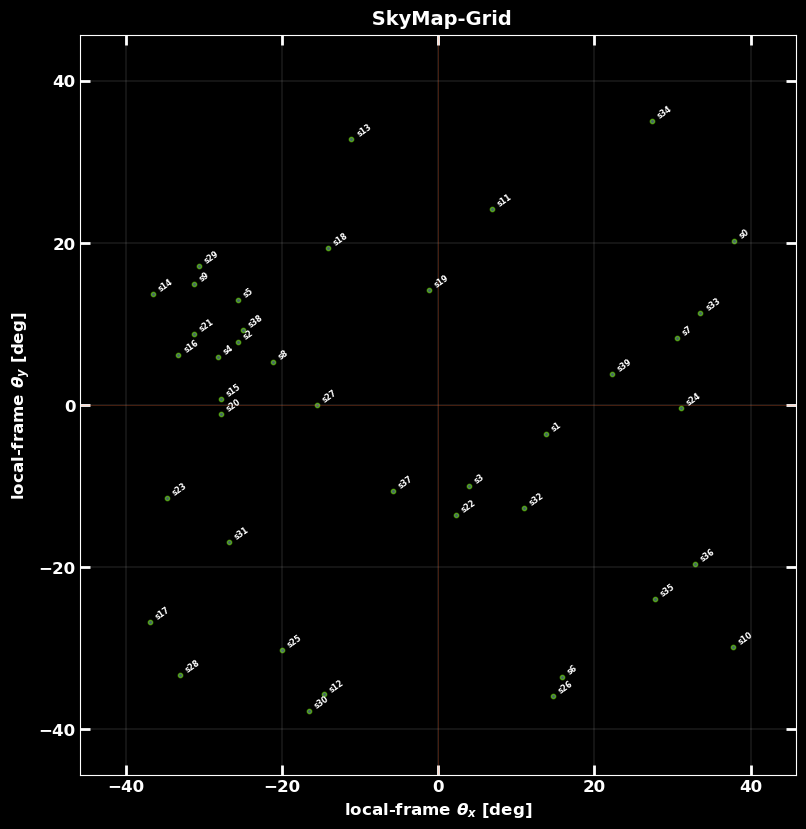

In [ ]:
sources: tuple[Source, ...] = get_sources(
    coords=coords,
    fluxes=fluxes,
)

params: tuple[LogEntry, ...] = (
    LogEntry('ID', 'A20', ''),
    LogEntry('angle_x', 'f8', 'deg'),
    LogEntry('angle_y', 'f8', 'deg'),
)
log: Log = ds.create_log(params)
log.add_entry_values('ID', [s.ID for s in sources])
log.add_entry_values('angle_x', [s.angle_x for s in sources])
log.add_entry_values('angle_y', [s.angle_y for s in sources])


SAVE_TO: str = '/home/edoardo/Desktop'
#SAVE_TO: str = '/mnt/d/PhD_AASS/Coding/Images_fits'

ds.skyfield_map(log, wfm, show_IDs=True, save_to=savefig_to(SAVE_TO, 'skymap', overwrite=True))

## **Testing LEM-X pointing**

In [ ]:
assert False

AssertionError: 

CAM1H
  Crab Source Position in the camera local-frame coords
  - shifts: (-52.55320588166768, -56.199841769251)
  - angles: (np.float64(-14.510818374736035), np.float64(-15.470935671066176))
  - RA - DEC: CoordEquatorial(ra=83.6332015991211, dec=22.014499664306626)
  - CAM pointings: {'z': CoordEquatorial(ra=65.6737015953277, dec=35.6486362123488), 'x': CoordEquatorial(ra=257.33165649948, dec=53.7838910823791)}
  - Wanted CAM pointings: CoordEquatorial(ra=83.1078519664901, dec=21.540083357047777)



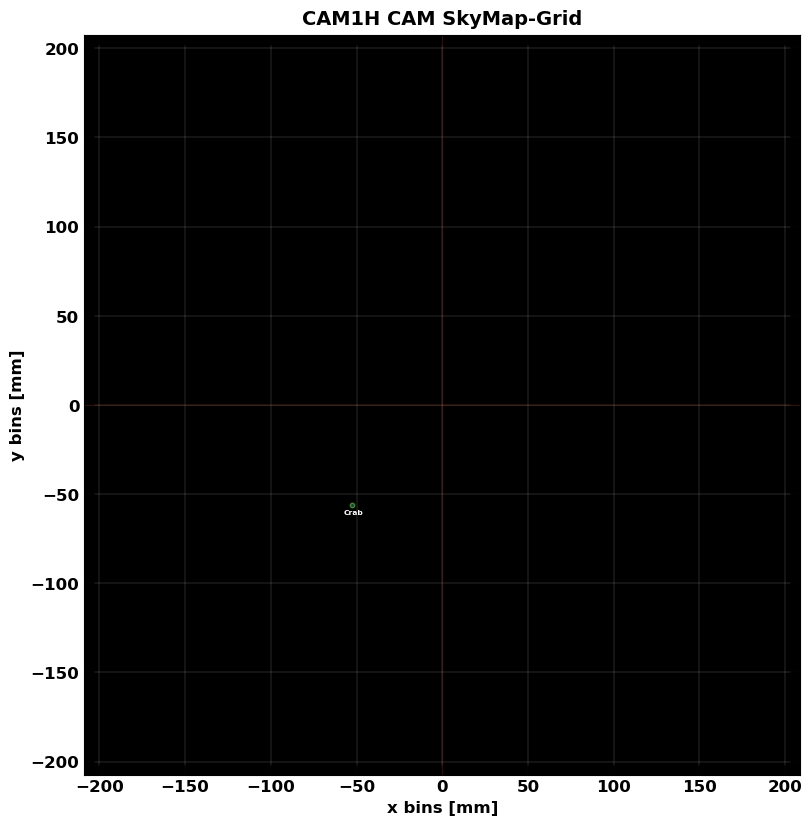

In [ ]:
from pathlib import Path

from bloodmoon.coords import equatorial2shift, shift2angle, shift2equatorial, angle2shift
from bloodmoon.mask import codedmask, count, decode

import darksun as ds
from darksun.types import LogEntry
from darksun.show import skyfield_map


# setup mask and data
base_path = '/home/edoardo/Datadisk/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'
skyfield = 'Crab/PointingTests'
mask_FITS = 'wfm_mask_NTHT_20250725.fits'
data_FITS = 'test_camera_tilt'
filepath = f'{base_path}/{skyfield}/{data_FITS}'

UPX, UPY = 1, 1
wfm = codedmask(f'{base_path}/{mask_FITS}', UPX, UPY)

CrabRA = 83.6332015991211
CrabDEC = 22.0144996643066
cameras = tuple(p.name for p in Path(filepath).glob('*cam1h*') if p.is_dir())


for camID in cameras:
    sdlA = ds.get_data(f'{filepath}/{camID}/{data_FITS}_{camID}_detected.fits')
    detector, _ = count(wfm, sdlA.DLdata)
    sky = decode(wfm, detector)
    shiftx, shifty = equatorial2shift(sdlA, wfm, CrabRA, CrabDEC)
    thetax, thetay = tuple(map(lambda x: shift2angle(wfm, x), (shiftx, shifty)))
    print(
        f'{camID.upper()}\n'
        f'  Crab Source Position in the camera local-frame coords\n'
        f'  - shifts: {shiftx, shifty}\n'
        f'  - angles: {thetax, thetay}\n'
        f'  - RA - DEC: {shift2equatorial(sdlA, wfm, shiftx, shifty)}\n'
        f'  - CAM pointings: {sdlA.pointings}\n'
        f'  - Wanted CAM pointings: {shift2equatorial(
            sdlA, wfm, angle2shift(wfm, -15.0), angle2shift(wfm, -15.0),
        )}\n'
    )

    # show source position in skymap
    params = (
        LogEntry('ID', '20A', ''), LogEntry('shift_x', 'D', 'mm'), LogEntry('shift_y', 'D', 'mm'),
    )
    source_log = ds.create_log(
        params=params,
        name=f'{camID} CAM'
    )
    source_log.update(tuple((p.entry, val) for p, val in zip(params, ('Crab', shiftx, shifty))))
    skyfield_map(
        log=source_log,
        camera=wfm,
    )